-  Mean, median, mode_ when each is appropriate
- Variance and standard deviation as measures of spread
- Percentiles, quartiles, IQR, and z-score
- Distribution shapes symmetric vs skewed, long tails, outlier detection with IQR fences
- When median and IQR are preferred over mean and standard deviation
- 

### Mean

In [18]:
import numpy as np 
import pandas as pd 

data=[120,123,124,145,455,677,345,789]
df=pd.DataFrame(data)

# mean
mean_value=df.mean() # Since you created a DataFrame from a list, pandas automatically gives that column a default column index → 0.
print("Mean:", mean_value)


#      0
# 0  120
# 1  123
# 2  124
# 3  145
# 4  455
# 5  677
# 6  345
# 7  789


Mean: 0    347.25
dtype: float64


In [19]:
import numpy as np 
import pandas as pd 

data=[120,123,124,145,455,677,345,789]
df=pd.DataFrame(data)

# mean
mean_value=df.mean()[0]
print("Mean:", mean_value)

Mean: 347.25


In [20]:
import numpy as np 
import pandas as pd 

data=[120,123,124,145,455,677,345,789]
df=pd.DataFrame(data)

# mean
mean_value = pd.Series(data)
print("Mean:", mean_value.mean())



Mean: 347.25


In [21]:
import numpy as np 
import pandas as pd 

data=[120,123,124,145,455,677,345,789]
df=pd.DataFrame({'HousePrice':data})

# mean
mean_value=df['HousePrice'].mean()
print("Mean:", mean_value)

Mean: 347.25


### Median

In [22]:
median_value=df['HousePrice'].median()
print("Median:",median_value)

Median: 245.0


#### Mode

In [23]:
df['City']=['Dhaka','Dhaka','Chittagong','Sylhet','Dhaka', 'Rajshahi', 'Chattogram','Khulna']

mode_value=df['City'].mode()[0]
print("Mode:",mode_value)

Mode: Dhaka


In [24]:
from sklearn.impute import SimpleImputer
imputer_mean=SimpleImputer(strategy='mean')
imputer_median =SimpleImputer(strategy='median')
imputer_mode=SimpleImputer(strategy='most_frequent')

# ----------------
# ----------------

In [ ]:
data = [10, 12, 13, 15, 18]
print("Variance:", np.var(data))
print("Standard Deviation:", np.std(data)) # best

Variance: 7.44
Standard Deviation: 2.727636339397171


In [26]:
import numpy as np
import pandas as pd

# Monthly customer purchase amounts
data = [120, 130, 125, 140, 135, 200, 220]
df = pd.DataFrame({'Purchase': data})

mean = np.mean(df['Purchase'])
pop_var = np.var(df['Purchase'], ddof=0)   # population variance
samp_var = np.var(df['Purchase'], ddof=1)  # sample variance
pop_sd = np.std(df['Purchase'], ddof=0)    # population SD
samp_sd = np.std(df['Purchase'], ddof=1)   # sample SD

print("Mean:", mean)
print("Population Variance:", pop_var)
print("Sample Variance:", samp_var)
print("Population SD:", pop_sd)
print("Sample SD:", samp_sd)
     

Mean: 152.85714285714286
Population Variance: 1370.4081632653058
Sample Variance: 1598.8095238095236
Population SD: 37.019024342428395
Sample SD: 39.98511627855449


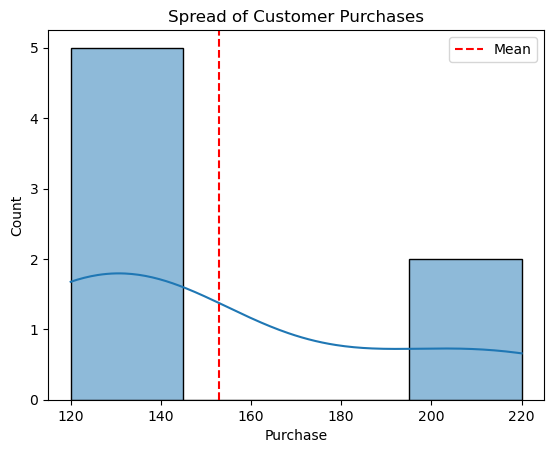

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Purchase'], kde=True)
plt.axvline(mean, color='red', linestyle='--', label='Mean')
plt.legend()
plt.title('Spread of Customer Purchases')
plt.show()

In [28]:
import numpy as np
data = [10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 34, 35, 37, 40]
print("25th percentile (Q1):", np.percentile(data, 25))
print("50th percentile (Median):", np.percentile(data, 50))
print("75th percentile (Q3):", np.percentile(data, 75))

25th percentile (Q1): 15.75
50th percentile (Median): 24.0
75th percentile (Q3): 33.0


In [ ]:
# type -->1
# s = pd.Series(data)
# Q1 = s.quantile(0.25)

# type->2
#Q1 = df['Purchase'].quantile(0.25)

#type -->3
#df.quantile(0.25)

#type -->4
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR:", IQR)
print("Outlier Range:", lower_bound, "to", upper_bound)

IQR: 17.25
Outlier Range: -10.125 to 58.875


In [30]:
import numpy as np

data = np.array([10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 34, 35, 37, 40])
mean = np.mean(data)
std = np.std(data)

z_scores = [(x - mean) / std for x in data]
print("Z-scores:", np.round(z_scores, 2))

Z-scores: [-1.5  -1.29 -1.19 -0.98 -0.66 -0.35 -0.14  0.07  0.38  0.59  1.01  1.11
  1.32  1.63]


In [31]:
import pandas as pd
import numpy as np

df = pd.DataFrame({'Income': [22, 25, 27, 29, 35, 40, 42, 100, 110, 115]})

# IQR 
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.0 * IQR
upper = Q3 + 1.0 * IQR
outliers_iqr = df[(df['Income'] < lower) | (df['Income'] > upper)]

print("Outliers using IQR:\n", outliers_iqr)


Outliers using IQR:
 Empty DataFrame
Columns: [Income]
Index: []


In [32]:
# Z-score 
mean = df['Income'].mean()
std = df['Income'].std()
df['z_score'] = (df['Income'] - mean) / std
outliers_z = df[np.abs(df['z_score']) > 2.5]
print("Outliers using Z-score:\n", outliers_z)



Outliers using Z-score:
 Empty DataFrame
Columns: [Income, z_score]
Index: []


1️⃣ Z-score আসলে কী?

Z-score বলে দেয়:
👉 কোনো মান (x) mean থেকে কত Standard Deviation দূরে

z = 0 → ঠিক mean

z = +1 → mean থেকে 1 SD উপরে

z = −2 → mean থেকে 2 SD নিচে


	​

Symbol	মানে
| Symbol   | মানে               |
| -------- | ------------------ |
| x        | data point         |
| μ / mean | গড়                 |
| σ / std  | standard deviation |


4️⃣ Z-score Range বুঝে নাও
| Z-score | Meaning           |
| ------- | ----------------- |
| 0       | Average           |
| ±1      | Normal            |
| ±2      | Rare              |
| ±3      | Extreme (Outlier) |



In [2]:
# Z-score use NumPy

import numpy as np

data = np.array([120,123,124,145,455,677,345,789])

mean = data.mean()
std = data.std()   # population std

z_scores = (data - mean) / std
print(z_scores)


[-0.9016637  -0.88976055 -0.88579284 -0.80247078  0.42752151  1.3083547
 -0.00892736  1.75273902]


In [3]:
# Z-score use Pandas

import pandas as pd

df = pd.DataFrame(data, columns=['value'])

df['z_score'] = (df['value'] - df['value'].mean()) / df['value'].std()
print(df)


   value   z_score
0    120 -0.843429
1    123 -0.832295
2    124 -0.828583
3    145 -0.750643
4    455  0.399910
5    677  1.223854
6    345 -0.008351
7    789  1.639537


In [33]:
# Modified Z-score (Robust)
median = df['Income'].median()
mad = np.median(np.abs(df['Income'] - median))
df['mod_z'] = 0.6745 * (df['Income'] - median) / mad
outliers_mz = df[np.abs(df['mod_z']) > 3.5]
print("Outliers using Modified Z-score:\n", outliers_mz)
# MAD = Median of those deviations

Outliers using Modified Z-score:
    Income   z_score     mod_z
7     100  1.202258  3.665761
8     110  1.466491  4.252283
9     115  1.598607  4.545543




## 1️⃣ Mean, Median, Mode — কী এবং কখন কোনটা ব্যবহার করবো?

### 🔹 Mean (গড়)

**সংজ্ঞা:**
সব মান যোগ করে মোট সংখ্যায় ভাগ দিলে যা পাওয়া যায়।

**উদাহরণ:**
ডেটা: `10, 20, 30`
Mean = (10+20+30)/3 = **20**

**কখন ব্যবহার করবো?**

* ডেটা যদি **balanced / symmetric** হয়
* **outlier না থাকে**

**সমস্যা:**
Outlier থাকলে mean খুব বেশি প্রভাবিত হয় ❌

**উদাহরণ:**
`10, 20, 30, 1000`
Mean = 265 😵 (বাস্তব অবস্থাকে ঠিক দেখায় না)

---

### 🔹 Median (মধ্যক)

**সংজ্ঞা:**
ডেটা সাজালে মাঝের মান

**উদাহরণ:**
`10, 20, 30` → Median = **20**
`10, 20, 30, 40` → (20+30)/2 = **25**

**কখন ব্যবহার করবো?**

* ডেটা **skewed**
* **outlier আছে**

👉 Salary, income, house price — এগুলোর জন্য **median best**

---

### 🔹 Mode (বহুলক)

**সংজ্ঞা:**
যে মানটা সবচেয়ে বেশি বার আসে

**উদাহরণ:**
`1, 2, 2, 3, 4` → Mode = **2**

**কখন ব্যবহার করবো?**

* **Categorical data**
  (যেমন: gender, color, brand)
* সবচেয়ে common value জানতে

---

### 📌 সারসংক্ষেপ

| Situation        | Best   |
| ---------------- | ------ |
| Normal data      | Mean   |
| Outlier / Skewed | Median |
| Most frequent    | Mode   |

---

## 2️⃣ Variance & Standard Deviation (Spread মাপা)

### 🔹 Spread মানে কী?

ডেটাগুলো mean থেকে **কতটা দূরে ছড়ানো**

---

### 🔹 Variance

**সংজ্ঞা:**
প্রতিটা মান mean থেকে কতটা দূরে — তার **square এর গড়**

* বড় variance → বেশি ছড়ানো
* ছোট variance → কাছাকাছি

**সমস্যা:**
Unit square হয়ে যায় (cm², টাকা²) — বুঝতে কষ্ট

---

### 🔹 Standard Deviation (SD)

**সংজ্ঞা:**
Variance এর square root

👉 **সবচেয়ে বেশি ব্যবহার হয়**

**কেন গুরুত্বপূর্ণ?**

* Risk
* Volatility
* Consistency বোঝা যায়

---

### 📌 উদাহরণ

| Data        | SD      |
| ----------- | ------- |
| 10, 11, 12  | Low SD  |
| 10, 50, 100 | High SD |

---

## 3️⃣ Percentiles, Quartiles, IQR, Z-score

---

### 🔹 Percentile

**সংজ্ঞা:**
আপনি ডেটার কত % এর উপরে / নিচে আছেন

**উদাহরণ:**
90th percentile মানে →
90% মানুষ আপনার নিচে

👉 Exam result, ranking

---

### 🔹 Quartiles

ডেটাকে ৪ ভাগে ভাগ করে

| Quartile | অর্থ         |
| -------- | ------------ |
| Q1       | 25%          |
| Q2       | 50% (Median) |
| Q3       | 75%          |

---

### 🔹 IQR (Interquartile Range)

**সংজ্ঞা:**
IQR = Q3 − Q1

👉 **Middle 50% data কতটা ছড়ানো**

**কেন দরকার?**

* Outlier ধরতে
* Skewed data বোঝতে

---

### 🔹 Z-score

**সংজ্ঞা:**
কোনো মান mean থেকে কত SD দূরে

[
z = \frac{x - mean}{SD}
]

**উদাহরণ:**
z = +2 → mean থেকে 2 SD উপরে
z = −1 → mean থেকে 1 SD নিচে

👉 Outlier detect
👉 Standardize data (ML)

---

## 4️⃣ Distribution Shape: Symmetric vs Skewed

---

### 🔹 Symmetric Distribution

* বাম আর ডান দিক সমান
* Mean ≈ Median ≈ Mode

**উদাহরণ:**
Height, IQ

---

### 🔹 Skewed Distribution

#### ➡️ Right Skewed (Positive skew)

* ডানদিকে লম্বা tail
* Mean > Median

**উদাহরণ:**
Income, salary

---

#### ⬅️ Left Skewed (Negative skew)

* বামদিকে লম্বা tail
* Mean < Median

**উদাহরণ:**
Easy exam marks

---

### 🔹 Long Tails

* Extreme values অনেক দূরে
* Risk বেশি
* Mean misleading

---

## 5️⃣ Outlier Detection — IQR Fence Method

**Lower fence:**
[
Q1 - 1.5 \times IQR
]

**Upper fence:**
[
Q3 + 1.5 \times IQR
]

👉 এর বাইরে থাকলে = **Outlier**

**কেন IQR ভালো?**

* Mean-এর মতো outlier sensitive না
* Robust method

---

## 6️⃣ Median + IQR কখন Mean + SD এর চেয়ে ভালো?

### Median & IQR ব্যবহার করবো যখন:

✅ Data skewed
✅ Extreme outlier আছে
✅ Income / price / medical data
✅ Real-world noisy data

---

### Mean & SD ব্যবহার করবো যখন:

✅ Data symmetric
✅ Outlier নেই
✅ Normal distribution

---

## 🧠 Final Cheat Sheet

| Data Type      | Best Measure  |
| -------------- | ------------- |
| Symmetric      | Mean + SD     |
| Skewed         | Median + IQR  |
| Ranking        | Percentile    |
| Outlier detect | IQR / Z-score |
| ML scaling     | Z-score       |


